# Evaluation: Response-Aware Dialogue Caching

In this notebook, we analyse the empirical results of the caching experiments (Phase 1 of the artefact evaluation). The goal is to validate the mechanics of the *Response-Aware Dialogue Caching* and quantify the operational savings generated by the growing dialogue tree.

### Experimental Setup
We simulate **30 dialogue repetitions** across **5 distinct cached roots** to simulate a CI/CD setting.

The setup used the following deterministic hyperparameters:
* **Context Expansion:** `alpha = 2`, `beta = 3`, `dir = below`
* **Validation:** `safeguard = True`
* **CG Persona:** `Your questions are very short and precise`

### Data Structure & Organisation
Each root is assigned a unique identifier (`root_id`). This ID serves as the primary key connecting all associated data files, which share the same UID in their filenames across different directories:
* **`tree/`**: Contains a `.json` file storing the recursive branches of the cache tree that grow from this root.
* **`conversations/`**: Contains the `.log` and `.jsonl` files of the generated multi-turn conversations.
* **`measurements/`**: Contains a `.jsonl` file logging the exact turn-by-turn metrics, including latency, token consumption, semantic similarity scores, and the Conversation Validator's (CV) accept/reject decisions.

During the simulation, the system always retrieved the cached node with the highest semantic similarity *without* enforcing a lower bound ($\tau$). For every interaction, the exact similarity score, the final accept or reject decision by the Conversation Validator (CV), execution latencies, and token consumption were logged. This continuous logging approach allows us to retrospectively simulate and evaluate the system's behaviour across various threshold limits in this notebook.

### Objectives of this Analysis

This notebook focuses on two core analyses:

1. **Similarity Threshold Calibration (Confusion Matrix)**
   By matching the logged similarity scores against the actual CV decisions, we construct a confusion matrix for varying $\tau$ values. We investigate the ratio of Safe Hits (True Positives) to Dangerous Hits (False Positives) to identify the empirical sweet spot that maximises cache utilisation while minimising costly CV rejections within our experimental setup.

2. **Cache Efficiency Over Time (Growth Plots)**
   We visualise the temporal development of the cache over the 30 iterations. Using the logged latency and token metrics, we demonstrate how the continuous expansion of the dialogue tree progressively reduces the need for fresh generations. These plots aim to confirm whether the caching mechanism delivers tangible operational value.

## Data Preparation

Connect multi-hop / single-hop flags, `type` and `logic_type` from the generated conversations with the measurements table and load everything to pandas. 

There is no direct link between the conversations `.jsonl` and the corresponding measurments table, but we can reconstruct the link from the `conversation_id`.

- turn 1 (initial multi-hop question) has no measurements, but we can set all cost functions to zero since the root is cached and does not need validation
- turns 2-5 correspond to the last four rows in the measurements table of every unique `conversation_id`. Logic: The measurements log one row per turn, even if a converation fails after `max_retries` and regenerates from turn 1, while the conversation only stores successfull dialogues of length $n$.
- if turn $m$ triggered a complete retry, the acumulated costs from regeneration until a successful $m$-turn get added to that dialogue turn.

In [12]:
import pandas as pd
import json
from pathlib import Path

measurements_dir = Path("measurements")
conversations_dir = Path("conversations")

all_merged_data = []

for meas_file in measurements_dir.glob("*.jsonl"):
    uid = meas_file.stem
    conv_file = conversations_dir / f"{uid}.jsonl"

    if not conv_file.exists():
        print(f"Warnung: Keine Conversation-Datei für UID {uid} gefunden.")
        continue

    df_meas = pd.read_json(meas_file, lines=True)

    conv_rows = []
    with open(conv_file, "r", encoding="utf-8") as f:
        for idx, line in enumerate(f):
            data = json.loads(line)
            conv_id = data.get("conversation_id", idx + 1)
            for turn in data.get("conversation", []):
                turn_idx = turn.get("turn_index", 0)
                conv_rows.append({
                    "conversation_id": conv_id,
                    "turn_index": turn_idx,
                    "multi_hop_flag": turn.get("multi_hop_flag"),
                    "type": turn.get("type"),
                    "logic_type": turn.get("logic_type"),
                })

    df_conv = pd.DataFrame(conv_rows)

    if df_conv.empty or df_meas.empty:
        continue

    # get number of follow-up-turns in dialgue
    turns_per_conv = df_conv[df_conv['turn_index'] > 0].groupby('conversation_id').size()

    cost_cols = ['gen_tokens_in', 'gen_tokens_out', 'val_tokens_in', 'val_tokens_out',
                 'total_turn_time_sec', 'generator_time_sec', 'validator_time_sec', 'rag_time_sec']

    processed_meas = []

    for conv_id, n_turns in turns_per_conv.items():
        meas_conv = df_meas[df_meas['conversation_id'] == conv_id].reset_index(drop=True)
        n_rows = len(meas_conv)

        if n_rows == 0:
            continue

        # last n rows = successful dialogue
        successful = meas_conv.tail(n_turns).copy()
        successful['retry_turns'] = 0
        successful['retry_cost_tokens'] = 0
        successful['retry_cost_time'] = 0.0

        # all prior = failed tries
        failed = meas_conv.head(n_rows - n_turns)

        if not failed.empty:
            # identify failed turn and sum all subsequent consts for regenerations up until that turn to it.
            fail_turn = int(failed.iloc[-1]['turn_index'])

            # Gesamte Retry-Kosten summieren
            retry_token_cost = failed[cost_cols[:4]].sum().sum()  
            retry_time_cost = failed[cost_cols[4:]].sum().sum()   
            retry_costs = failed[cost_cols].sum()

            fail_mask = successful['turn_index'] == fail_turn
            if fail_mask.any():
                fail_idx = successful[fail_mask].index[0]
                for col in cost_cols:
                    if col in successful.columns:
                        successful.loc[fail_idx, col] += retry_costs[col]
                successful.loc[fail_idx, 'retry_turns'] = len(failed)
                successful.loc[fail_idx, 'retry_cost_tokens'] = retry_token_cost
                successful.loc[fail_idx, 'retry_cost_time'] = retry_time_cost

        processed_meas.append(successful)

    if not processed_meas:
        continue

    df_meas_clean = pd.concat(processed_meas, ignore_index=True)

    # merge table to conversations
    df_merged = pd.merge(df_conv, df_meas_clean, on=["conversation_id", "turn_index"], how="left")

    # Turn 0 = Root --> no costs
    meas_cols = [c for c in df_meas_clean.columns if c not in ["conversation_id", "turn_index"]]
    df_merged.loc[df_merged["turn_index"] == 0, meas_cols] = 0
    df_merged.insert(0, "uid", uid)

    all_merged_data.append(df_merged)

if all_merged_data:
    df = pd.concat(all_merged_data, ignore_index=True)
    print(f"Success! {len(df)} Turns from {len(all_merged_data)} files.")
    print(f"Includes costs of {df['retry_turns'].sum():.0f} Retry-Turns.")
    df.to_csv("evaluation_dataset_full.csv", index=False)
    print(df.head(10))
else:
    print("No files merged")

Success! 750 Turns from 5 files.
Includes costs of 26 Retry-Turns.
                                    uid  conversation_id  turn_index  \
0  bfeeeccc-65bf-4dfd-bff6-483a1d9e6fe1                1           0   
1  bfeeeccc-65bf-4dfd-bff6-483a1d9e6fe1                1           1   
2  bfeeeccc-65bf-4dfd-bff6-483a1d9e6fe1                1           2   
3  bfeeeccc-65bf-4dfd-bff6-483a1d9e6fe1                1           3   
4  bfeeeccc-65bf-4dfd-bff6-483a1d9e6fe1                1           4   
5  bfeeeccc-65bf-4dfd-bff6-483a1d9e6fe1                2           0   
6  bfeeeccc-65bf-4dfd-bff6-483a1d9e6fe1                2           1   
7  bfeeeccc-65bf-4dfd-bff6-483a1d9e6fe1                2           2   
8  bfeeeccc-65bf-4dfd-bff6-483a1d9e6fe1                2           3   
9  bfeeeccc-65bf-4dfd-bff6-483a1d9e6fe1                2           4   

   multi_hop_flag         type  logic_type cache_available  candidates_count  \
0               1      Initial  comparison               0  

## Results & Graphs

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.lines as mlines
from matplotlib.lines import Line2D
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import networkx as nx
from collections import defaultdict
import numpy as np

df = pd.read_csv("evaluation_dataset_full.csv")

# ============ GLOBALES STYLING ============
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'font.family': 'sans-serif'})

C_PRIMARY = '#1a5276'
C_SECONDARY = '#c0392b'
C_TERTIARY = '#f39c12'
C_QUATERNARY = '#27ae60'
C_ACCENT = '#8e44ad'
C_DARK = '#2c3e50'

BAR_COLORS = [C_PRIMARY, C_SECONDARY, C_TERTIARY, C_QUATERNARY]
TIME_COLORS = [C_PRIMARY, C_SECONDARY, C_TERTIARY]
CMAP_MAIN = sns.light_palette(C_PRIMARY, as_cmap=True)
CMAP_DIV = sns.diverging_palette(220, 10, s=80, l=50, as_cmap=True)

def get_turn_palette(n):
    base = [C_PRIMARY, C_QUATERNARY, C_TERTIARY, C_SECONDARY, C_ACCENT, C_DARK]
    return sns.color_palette(base[:n], n) if n <= len(base) else sns.color_palette(base, n)

### 1. Explore if cache trees reach saturation point with regplots

**AI-Notice**: a first draft of all plot-related code was generated by `Claude Opus 4.6`, but carefully reviewed and updated by Daniel Hillebrand

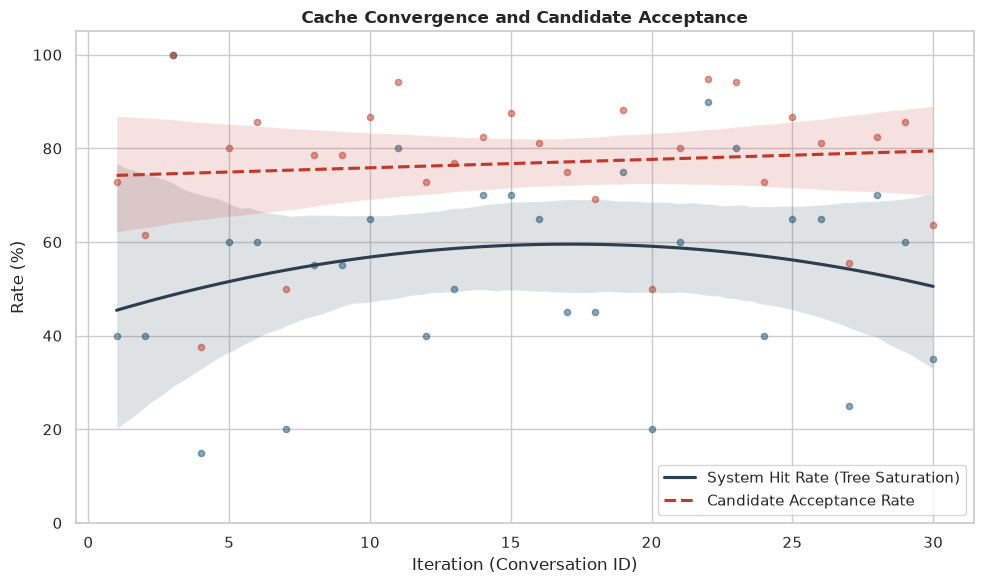

In [19]:
# data preparation
df_ongoing = df[df['turn_index'] > 0].copy()
df_ongoing['cache_accepted'] = df_ongoing['cache_accepted_and_used'].isin([True, 'True', 1, 1.0])
df_ongoing['cache_avail'] = df_ongoing['cache_available'].isin([True, 'True', 1, 1.0])

# calculate cache hit rate
system_hit_rate = df_ongoing.groupby('conversation_id')['cache_accepted'].mean() * 100

# calculate cv acceptence rate of cache
df_candidates_only = df_ongoing[df_ongoing['cache_avail'] == True]
acceptance_rate = df_candidates_only.groupby('conversation_id')['cache_accepted'].mean() * 100


# plot
plt.figure(figsize=(10, 6))
sns.regplot(x=system_hit_rate.index, y=system_hit_rate.values,
            scatter_kws={'alpha': 0.5, 'color': C_PRIMARY, 's': 20},
            line_kws={'color': C_DARK, 'label': 'System Hit Rate (Tree Saturation)'},
            order=2)
sns.regplot(x=acceptance_rate.index, y=acceptance_rate.values,
            scatter_kws={'alpha': 0.5, 'color': C_SECONDARY, 'marker': 'x', 's': 20},
            line_kws={'color': C_SECONDARY, 'linestyle': '--', 'label': 'Candidate Acceptance Rate'},
            order=1)
plt.title('Cache Convergence and Candidate Acceptance', fontweight='bold')
plt.xlabel('Iteration (Conversation ID)')
plt.ylabel('Rate (%)')
plt.ylim(0, 105)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('cache_convergence_combined.pdf')
plt.show()

### 2. CV cache acceptance rate over conversational turns and iterations

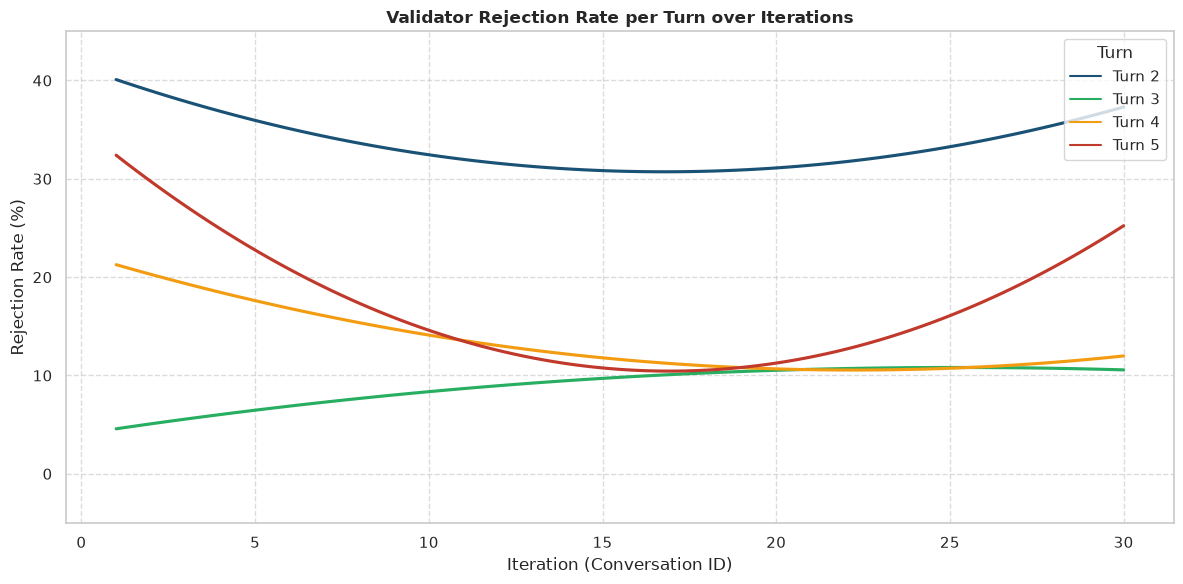

In [21]:
df_validatable = df[df['cache_available'].isin([True, 'True', 1, 1.0])].copy()
df_validatable['validator_passed_num'] = pd.to_numeric(df_validatable['validator_passed'], errors='coerce')
df_clean = df_validatable.dropna(subset=['validator_passed_num', 'turn_index'])
df_clean['rejected'] = (df_clean['validator_passed_num'] == 0).astype(int) * 100

plt.figure(figsize=(12, 6))
n_turns = len(df_clean['turn_index'].unique())
palette = get_turn_palette(n_turns)

handles = []
for idx, turn in enumerate(sorted(df_clean['turn_index'].unique())):
    subset = df_clean[df_clean['turn_index'] == turn]
    color = palette[idx]
    sns.regplot(x='conversation_id', y='rejected', data=subset,
                scatter=False, color=color, line_kws={}, order=2, ci=None)
    handles.append(mlines.Line2D([], [], color=color, label=f'Turn {int(turn) + 1}'))

plt.legend(handles=handles, title='Turn', loc='upper right')
plt.title('Validator Rejection Rate per Turn over Iterations', fontweight='bold')
plt.xlabel('Iteration (Conversation ID)')
plt.ylabel('Rejection Rate (%)')
plt.ylim(-5, 45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('rejection_rate_per_turn.pdf')
plt.show()

### 3. Confusion Matrix for varios tau-values

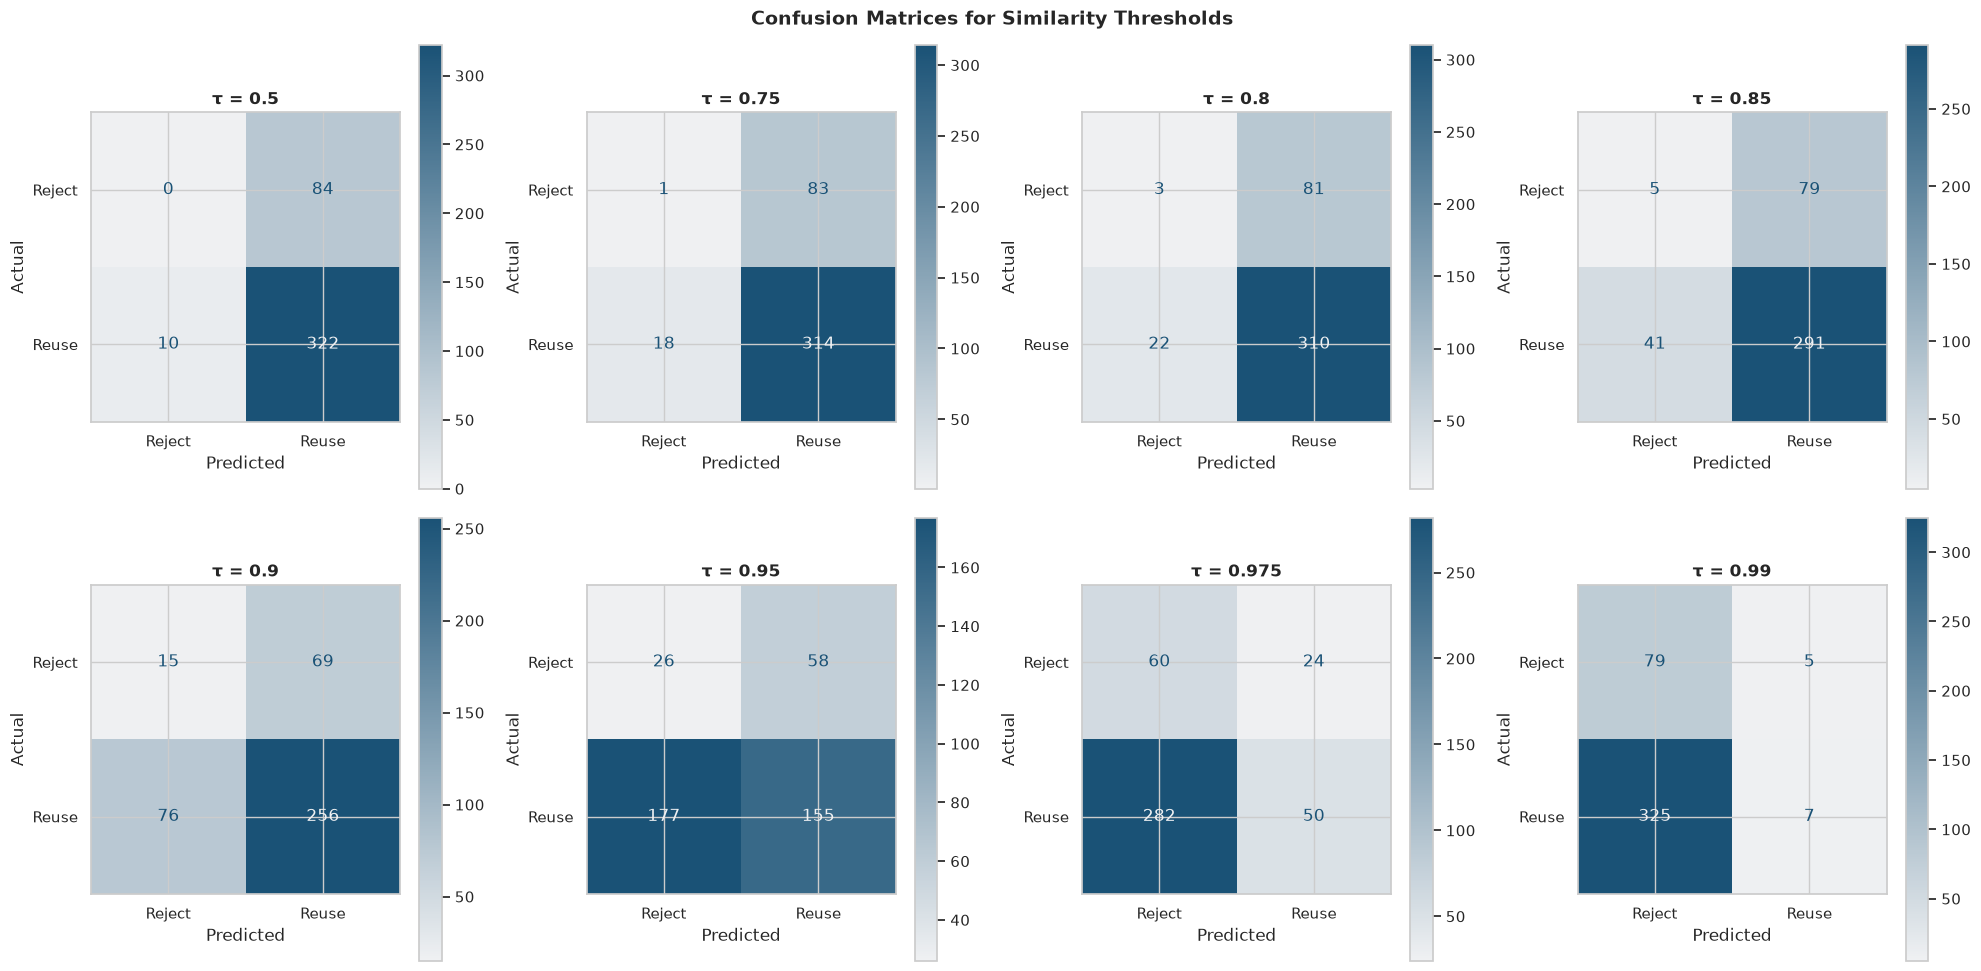

In [22]:
df_cache = df[df['cache_available'].isin([True, 'True', 1, 1.0])].copy()
df_cache['accepted'] = df_cache['cache_accepted_and_used'].isin([True, 'True', 1, 1.0]).astype(int)
df_cache['highest_sim'] = pd.to_numeric(df_cache['highest_sim'], errors='coerce')
df_cache = df_cache.dropna(subset=['highest_sim'])

thresholds = [0.5, 0.75, 0.8, 0.85, 0.9, 0.95, 0.975, 0.99]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()
for i, tau in enumerate(thresholds):
    predicted = (df_cache['highest_sim'] >= tau).astype(int)
    actual = df_cache['accepted']
    cm = confusion_matrix(actual, predicted, labels=[0, 1])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Reject', 'Reuse'])
    disp.plot(ax=axes[i], cmap=CMAP_MAIN, values_format='d')
    axes[i].set_title(f'τ = {tau}', fontweight='bold')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
plt.suptitle('Confusion Matrices for Similarity Thresholds', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('confusion_matrices_thresholds.pdf')
plt.show()

### 4. Cost Assessment of Cache Hits / Cache Rejects / No Cache (Pure Gen)

=== Avg Cost per Scenario ===
                    Cache Accepted  Cache Rejected\n→ Generated  \
gen_tokens_in                60.72                      1977.27   
gen_tokens_out               10.68                       380.90   
val_tokens_in              2749.23                      5678.88   
val_tokens_out             1006.72                      1755.98   
generator_time_sec            0.06                         2.38   
validator_time_sec           12.15                        21.10   
rag_time_sec                 12.51                        15.44   

                    No Cache\n→ Generated  
gen_tokens_in                     7842.14  
gen_tokens_out                     434.47  
val_tokens_in                    12229.23  
val_tokens_out                    2220.66  
generator_time_sec                   2.76  
validator_time_sec                  26.49  
rag_time_sec                        13.81  

N: {'Cache Accepted': 332, 'Cache Rejected\n→ Generated': 84, 'No Cache\n→ Gener

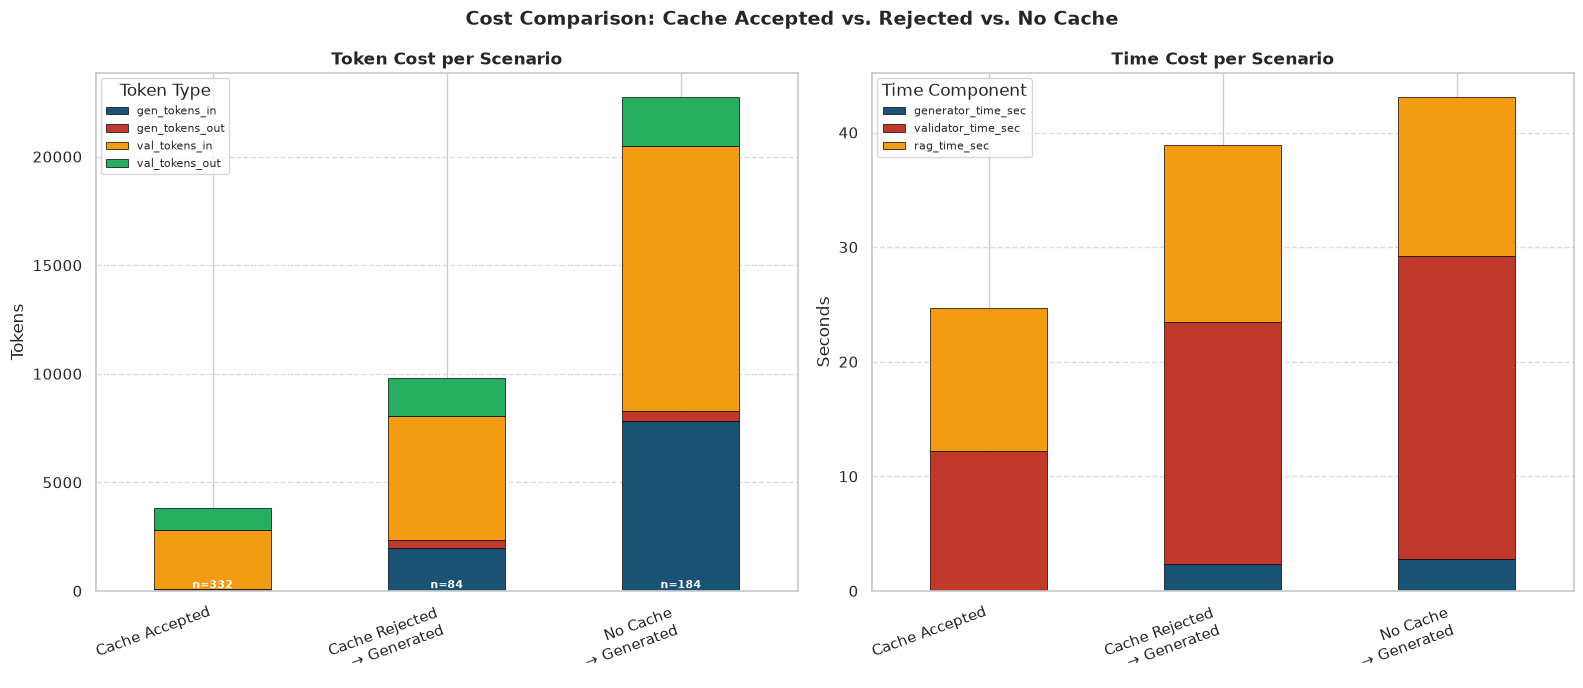

In [46]:
df_turns = df[df['turn_index'] > 0].copy()
df_turns['cache_accepted'] = df_turns['cache_accepted_and_used'].isin([True, 'True', 1, 1.0])
df_turns['cache_avail'] = df_turns['cache_available'].isin([True, 'True', 1, 1.0])

token_cols = ['gen_tokens_in', 'gen_tokens_out', 'val_tokens_in', 'val_tokens_out']
time_cols = ['generator_time_sec', 'validator_time_sec', 'rag_time_sec']
for col in token_cols + time_cols:
    df_turns[col] = pd.to_numeric(df_turns[col], errors='coerce').fillna(0)

df_accepted = df_turns[df_turns['cache_accepted']]
df_rejected = df_turns[(df_turns['cache_avail']) & (~df_turns['cache_accepted'])]
df_nocache = df_turns[~df_turns['cache_avail']]

scenarios = {
    'Cache Accepted': df_accepted,
    'Cache Rejected\n→ Generated': df_rejected,
    'No Cache\n→ Generated': df_nocache,
}
scenarios = {k: v for k, v in scenarios.items() if len(v) > 0}

summary = pd.DataFrame({
    name: grp[token_cols + time_cols].mean()
    for name, grp in scenarios.items()
})

counts = {k: len(v) for k, v in scenarios.items()}
print("=== Avg Cost per Scenario ===")
print(summary.round(2))
print(f"\nN: {counts}")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

summary.loc[token_cols].T.plot(kind='bar', stacked=True, ax=axes[0],
    color=BAR_COLORS, edgecolor='black', linewidth=0.5)
axes[0].set_title('Token Cost per Scenario', fontweight='bold')
axes[0].set_ylabel('Tokens')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=20, ha='right')
axes[0].legend(title='Token Type', loc='upper left', fontsize=8)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
for i, (name, count) in enumerate(counts.items()):
    axes[0].text(i, 5, f'n={count}', ha='center', va='bottom', fontsize=8, fontweight='bold', color='white')

summary.loc[time_cols].T.plot(kind='bar', stacked=True, ax=axes[1],
    color=TIME_COLORS, edgecolor='black', linewidth=0.5)
axes[1].set_title('Time Cost per Scenario', fontweight='bold')
axes[1].set_ylabel('Seconds')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=20, ha='right')
axes[1].legend(title='Time Component', loc='upper left', fontsize=8)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle('Cost Comparison: Cache Accepted vs. Rejected vs. No Cache',
    fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('cost_comparison.pdf')
plt.show()

### Plotting the Cache-Trees

Thicker lines -> parent was used more often -> visualise the most popular conversational path

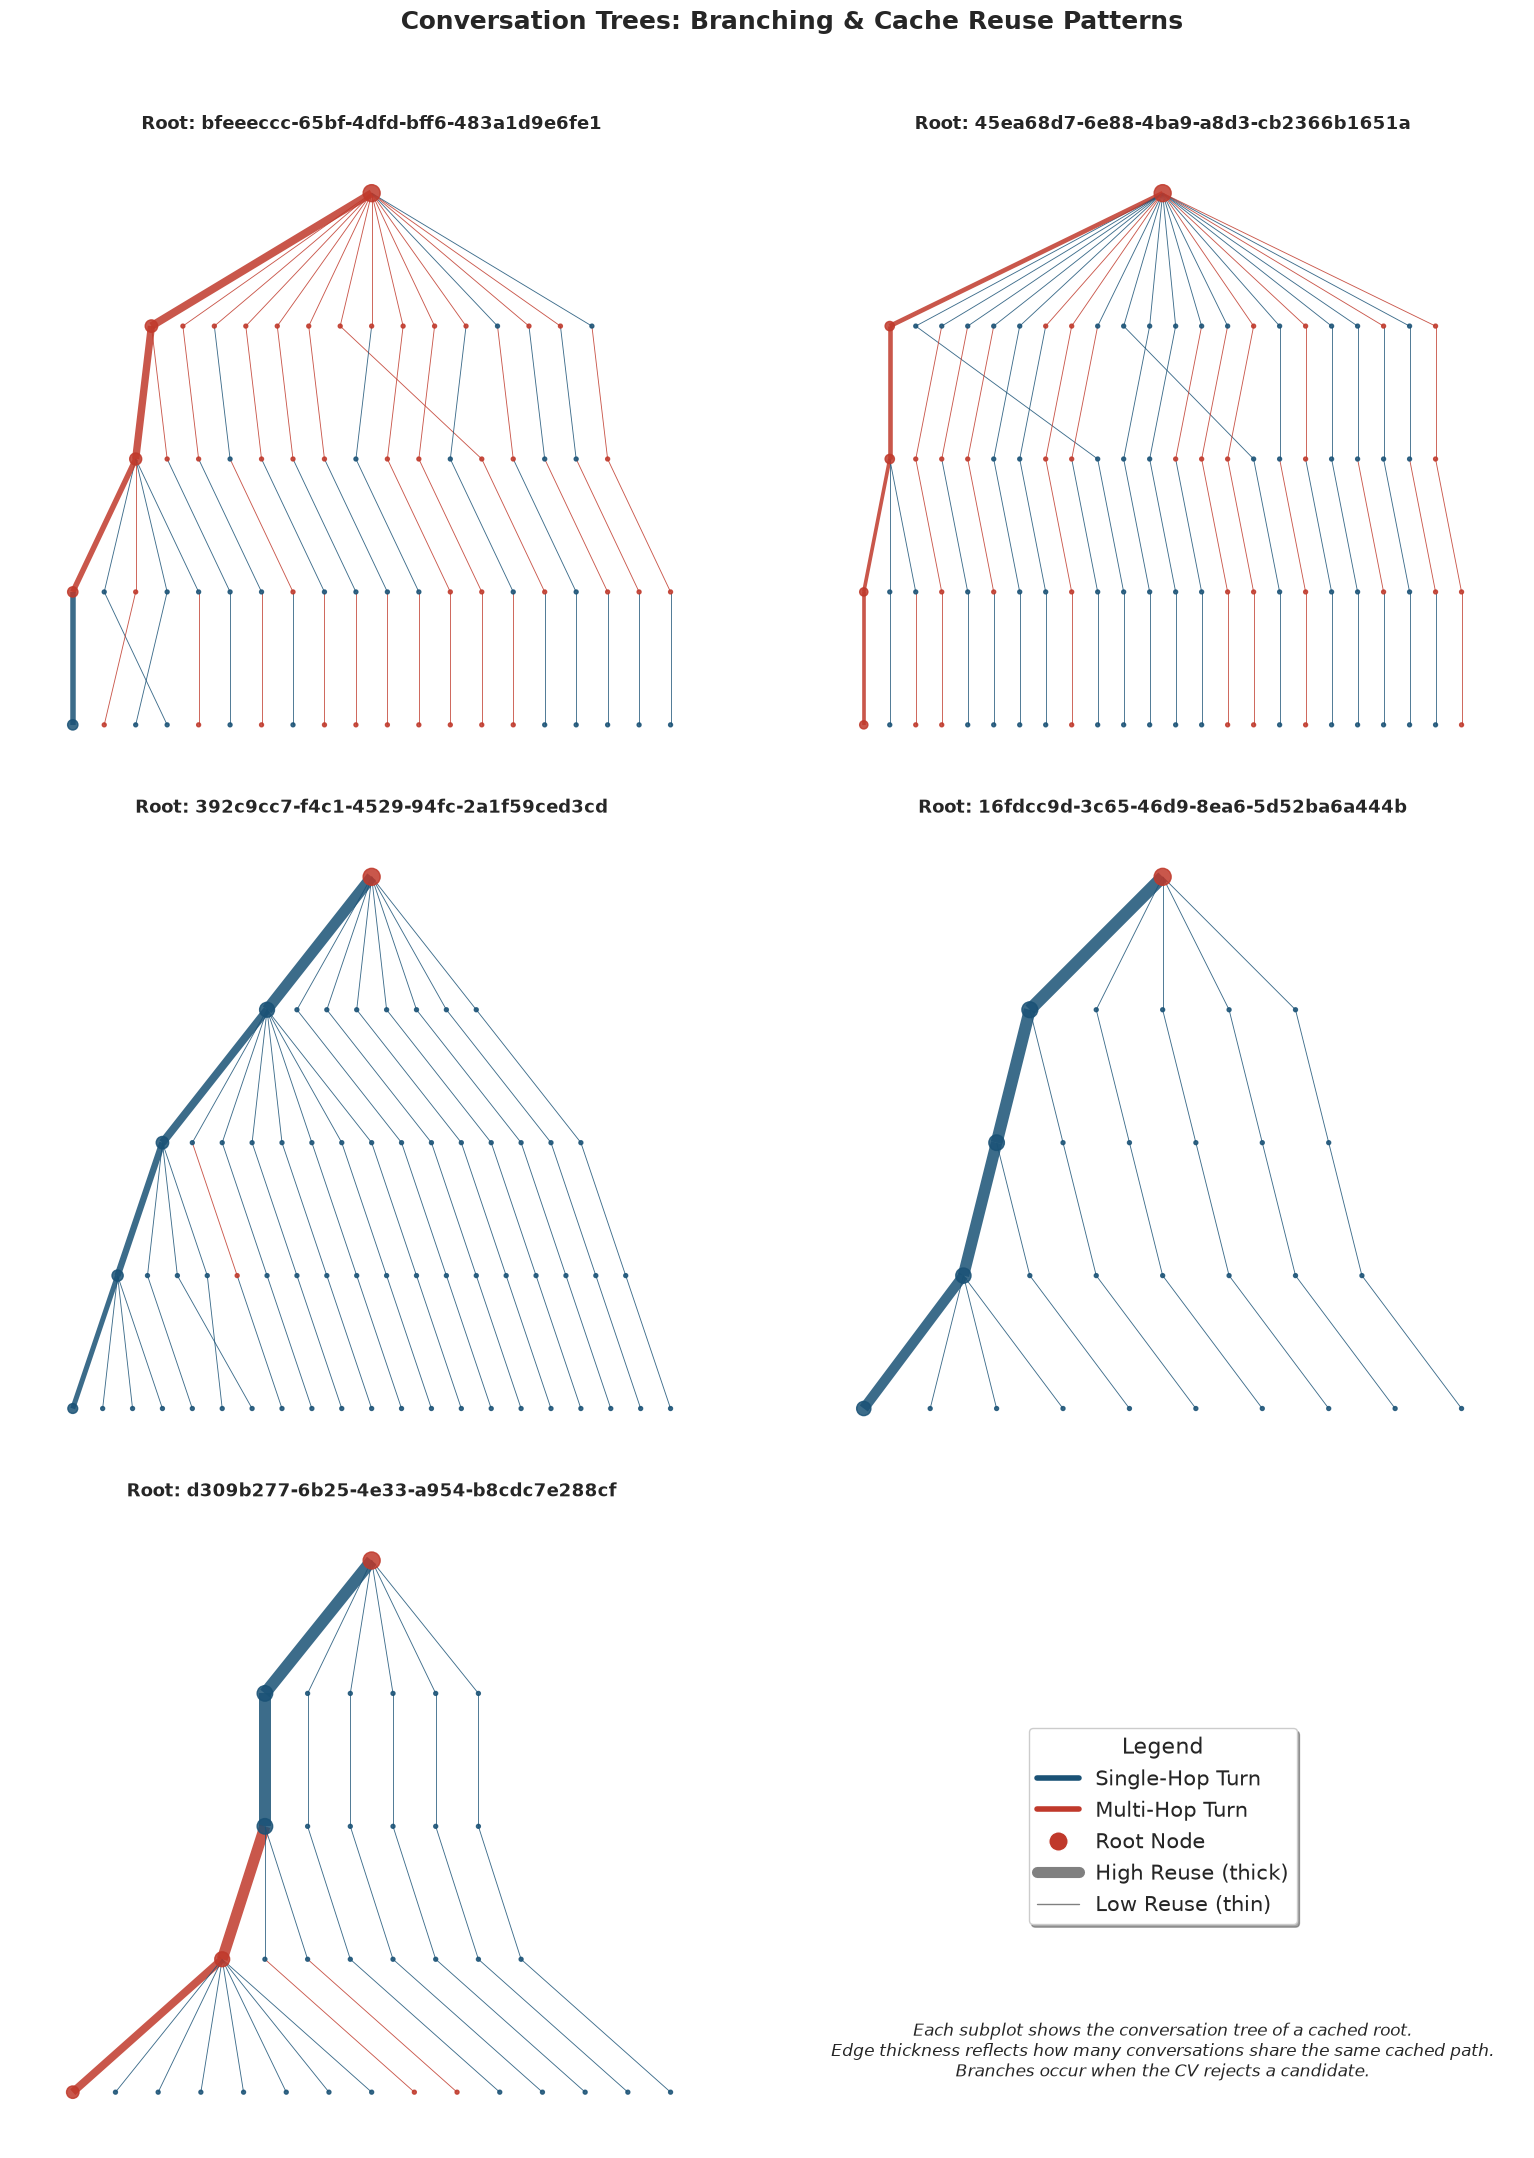

In [41]:
uids = df['uid'].unique()[:5]
fig, axes = plt.subplots(3, 2, figsize=(16, 22))
axes = axes.flatten()

for ax_idx, uid in enumerate(uids):
    df_tree = df[df['uid'] == uid].copy()
    df_tree['multi_hop'] = df_tree['multi_hop_flag'].isin([True, 'True', 1, 1.0])
    df_tree['cache_hit'] = df_tree['cache_accepted_and_used'].isin([True, 'True', 1, 1.0])

    G = nx.DiGraph()
    G.add_node("ROOT", multi_hop=False, depth=0)
    node_counts = defaultdict(int)

    for conv_id in sorted(df_tree['conversation_id'].unique()):
        conv = df_tree[df_tree['conversation_id'] == conv_id].sort_values('turn_index')
        parent = "ROOT"
        node_counts["ROOT"] += 1

        for _, row in conv.iterrows():
            turn = int(row['turn_index'])
            if turn == 0:
                continue
            if row['cache_hit']:
                node_id = f"{parent}>>T{turn}_hit"
            else:
                node_id = f"{parent}>>T{turn}_miss_{conv_id}"

            if not G.has_node(node_id):
                G.add_node(node_id, multi_hop=row['multi_hop'], depth=turn)
            node_counts[node_id] += 1
            if not G.has_edge(parent, node_id):
                G.add_edge(parent, node_id)
            parent = node_id

    pos = {"ROOT": (0, 0)}
    max_depth = int(df_tree['turn_index'].max())
    for depth in range(1, max_depth + 1):
        nodes_at_depth = sorted([n for n, d in G.nodes(data=True) if d.get('depth') == depth])
        for i, node in enumerate(nodes_at_depth):
            pos[node] = ((i - (len(nodes_at_depth) - 1) / 2), -depth)

    max_count = max(node_counts.values()) if node_counts else 1
    edge_widths = [node_counts.get(v, 1) / max_count * 10 + 0.3 for u, v in G.edges()]
    edge_colors = [C_SECONDARY if G.nodes[v].get('multi_hop') else C_PRIMARY for u, v in G.edges()]

    node_colors = []
    node_sizes = []
    for n in G.nodes():
        if n == "ROOT":
            node_colors.append(C_SECONDARY)
        elif G.nodes[n].get('multi_hop'):
            node_colors.append(C_SECONDARY)
        else:
            node_colors.append(C_PRIMARY)
        node_sizes.append(max(node_counts.get(n, 1) / max_count * 150, 8))

    nx.draw(G, pos, ax=axes[ax_idx],
            node_size=node_sizes, node_color=node_colors,
            edge_color=edge_colors, width=edge_widths,
            arrows=False, alpha=0.85)
    axes[ax_idx].set_title(f'Root: {uid}', fontweight='bold', fontsize=13)

# Legende im letzten Subplot
axes[5].axis('off')
legend_handles = [
    Line2D([0], [0], color=C_PRIMARY, linewidth=4, label='Single-Hop Turn'),
    Line2D([0], [0], color=C_SECONDARY, linewidth=4, label='Multi-Hop Turn'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=C_SECONDARY, markersize=14, label='Root Node'),
    Line2D([0], [0], color='grey', linewidth=8, label='High Reuse (thick)'),
    Line2D([0], [0], color='grey', linewidth=1, label='Low Reuse (thin)'),
]
axes[5].legend(handles=legend_handles, loc='center', fontsize=15, frameon=True,
               fancybox=True, shadow=True, title='Legend', title_fontsize=16)
axes[5].text(0.5, 0.15,
    'Each subplot shows the conversation tree of a cached root.\n'
    'Edge thickness reflects how many conversations share the same cached path.\n'
    'Branches occur when the CV rejects a candidate.',
    ha='center', va='center', fontsize=12, style='italic',
    transform=axes[5].transAxes, wrap=True)

plt.suptitle('Conversation Trees: Branching & Cache Reuse Patterns',
             fontweight='bold', fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('conversation_trees.pdf')
plt.show()

### 6. Cache-Likelihood Single-Hop VS Multi-Hop

            Cache Available (%)  Cache Hit Rate - All (%)  \
Single-Hop                71.71                     57.68   
Multi-Hop                 61.81                     47.92   

            Cache Hit Rate - If Available (%)    N  
Single-Hop                              80.43  456  
Multi-Hop                               77.53  144  


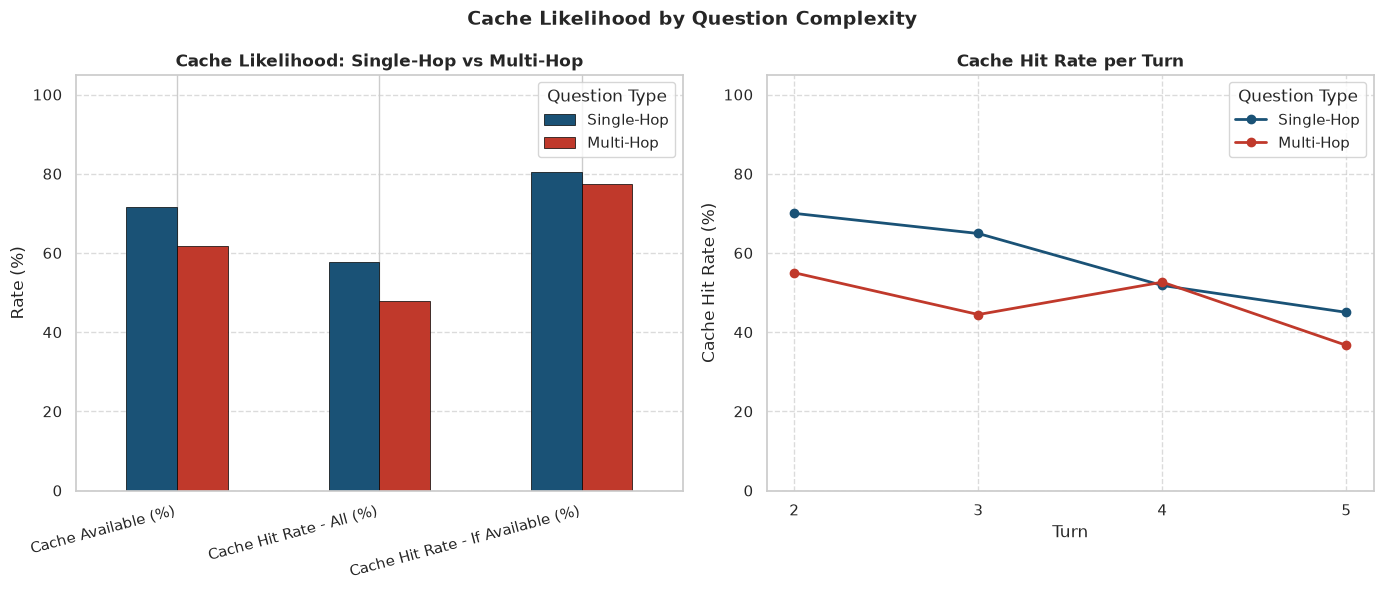

In [43]:
df_turns = df[df['turn_index'] > 0].copy()
df_turns['multi_hop'] = df_turns['multi_hop_flag'].isin([True, 'True', 1, 1.0])
df_turns['cache_avail'] = df_turns['cache_available'].isin([True, 'True', 1, 1.0])
df_turns['cache_hit'] = df_turns['cache_accepted_and_used'].isin([True, 'True', 1, 1.0])

avail = df_turns.groupby('multi_hop')['cache_avail'].mean() * 100
hit_all = df_turns.groupby('multi_hop')['cache_hit'].mean() * 100
df_avail_only = df_turns[df_turns['cache_avail']]
hit_if_avail = df_avail_only.groupby('multi_hop')['cache_hit'].mean() * 100

hop_summary = pd.DataFrame({
    'Cache Available (%)': avail,
    'Cache Hit Rate - All (%)': hit_all,
    'Cache Hit Rate - If Available (%)': hit_if_avail,
    'N': df_turns.groupby('multi_hop').size()
})
hop_summary.index = ['Single-Hop', 'Multi-Hop']
print(hop_summary.round(2))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

plot_data = hop_summary[['Cache Available (%)', 'Cache Hit Rate - All (%)', 'Cache Hit Rate - If Available (%)']].T
plot_data.plot(kind='bar', ax=ax1, color=[C_PRIMARY, C_SECONDARY], edgecolor='black', linewidth=0.5)
ax1.set_title('Cache Likelihood: Single-Hop vs Multi-Hop', fontweight='bold')
ax1.set_ylabel('Rate (%)')
ax1.set_ylim(0, 105)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=15, ha='right')
ax1.legend(title='Question Type')
ax1.grid(axis='y', linestyle='--', alpha=0.7)

turn_hop = df_turns.groupby(['turn_index', 'multi_hop'])['cache_hit'].mean().unstack() * 100
turn_hop.columns = ['Single-Hop', 'Multi-Hop']
turn_hop.index = turn_hop.index.astype(int) + 1

turn_hop.plot(ax=ax2, marker='o', color=[C_PRIMARY, C_SECONDARY], linewidth=2)
ax2.set_title('Cache Hit Rate per Turn', fontweight='bold')
ax2.set_xlabel('Turn')
ax2.set_ylabel('Cache Hit Rate (%)')
ax2.set_ylim(0, 105)
ax2.set_xticks(turn_hop.index.astype(int))
ax2.legend(title='Question Type')
ax2.grid(True, linestyle='--', alpha=0.7)

plt.suptitle('Cache Likelihood by Question Complexity', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('cache_likelihood_hop_turns.pdf')
plt.show()

### 7. Caching-Likelihood Heatmap per Tree and Turn

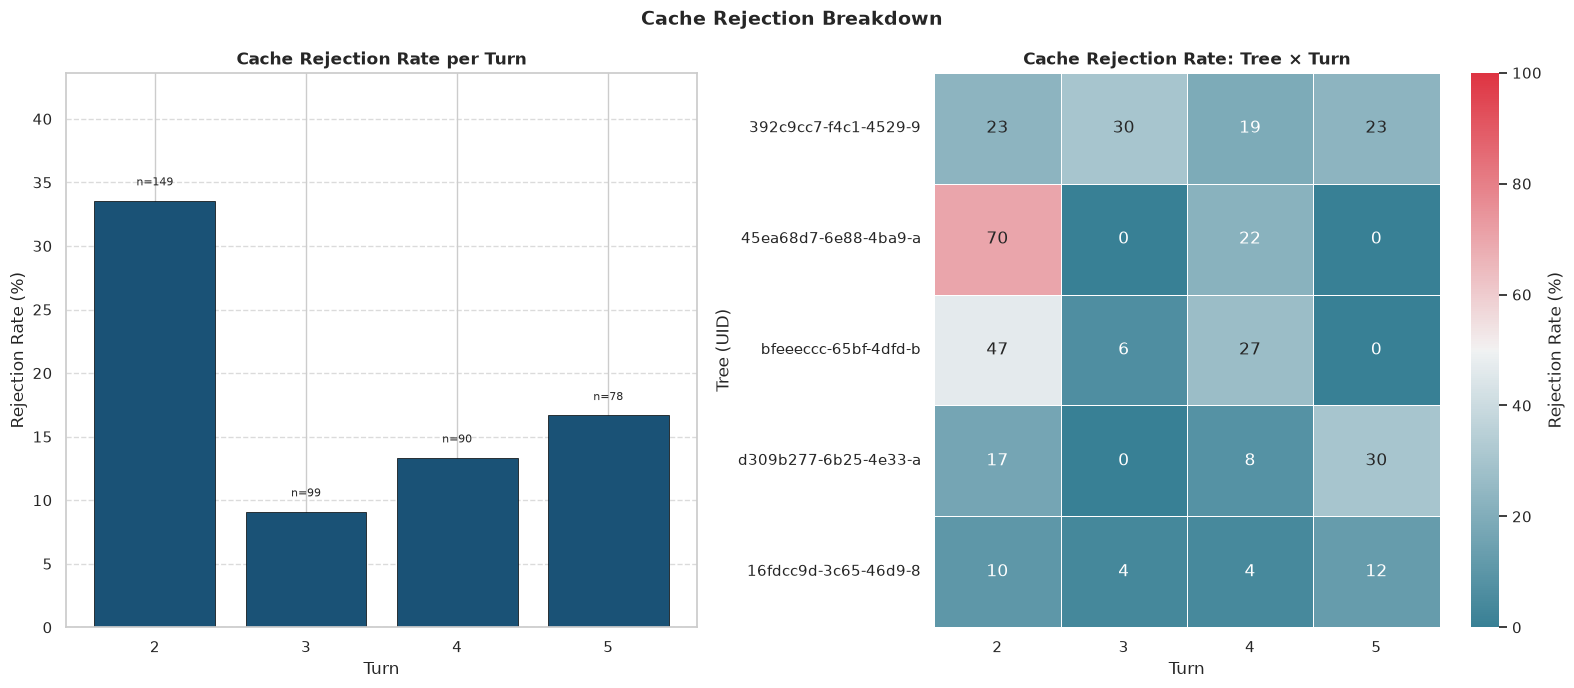

In [44]:
df_turns2 = df[df['turn_index'] > 0].copy()
df_turns2['cache_avail'] = df_turns2['cache_available'].isin([True, 'True', 1, 1.0])
df_turns2['cache_hit'] = df_turns2['cache_accepted_and_used'].isin([True, 'True', 1, 1.0])
df_cache2 = df_turns2[df_turns2['cache_avail']].copy()
df_cache2['rejected'] = (~df_cache2['cache_hit']).astype(int) * 100
df_cache2['turn_label'] = (df_cache2['turn_index'].astype(int) + 1).astype(str)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

turn_rej = df_cache2.groupby('turn_label')['rejected'].agg(['mean', 'count'])
turn_rej.columns = ['Rejection Rate (%)', 'N']
bars = ax1.bar(turn_rej.index, turn_rej['Rejection Rate (%)'], color=C_PRIMARY, edgecolor='black', linewidth=0.5)
for bar, n in zip(bars, turn_rej['N']):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
             f'n={n}', ha='center', va='bottom', fontsize=8)
ax1.set_title('Cache Rejection Rate per Turn', fontweight='bold')
ax1.set_xlabel('Turn')
ax1.set_ylabel('Rejection Rate (%)')
ax1.set_ylim(0, max(turn_rej['Rejection Rate (%)'].max() * 1.3, 10))
ax1.grid(axis='y', linestyle='--', alpha=0.7)

pivot = df_cache2.pivot_table(index='uid', columns='turn_index', values='rejected', aggfunc='mean')
pivot.columns = (pivot.columns.astype(int) + 1).astype(str)
pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]
pivot.index = [u[:20] for u in pivot.index]

sns.heatmap(pivot, ax=ax2, cmap=CMAP_DIV, annot=True, fmt='.0f',
            vmin=0, vmax=100, linewidths=0.5, center=50,
            cbar_kws={'label': 'Rejection Rate (%)'})
ax2.set_title('Cache Rejection Rate: Tree × Turn', fontweight='bold')
ax2.set_xlabel('Turn')
ax2.set_ylabel('Tree (UID)')

plt.suptitle('Cache Rejection Breakdown', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('cache_rejection_breakdown.pdf')
plt.show()